<a href="https://colab.research.google.com/github/santiagorodmon/TelecomX_LATAM/blob/main/01_extraccion_datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📌 Extracción

In [1]:
!git clone https://github.com/santiagorodmon/TelecomX_LATAM.git
%cd TelecomX_LATAM

Cloning into 'TelecomX_LATAM'...
remote: Enumerating objects: 16, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 16 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (16/16), 14.30 KiB | 7.15 MiB/s, done.
/content/TelecomX_LATAM


In [2]:
import pandas as pd

In [3]:
datos = pd.read_json('https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json')
datos.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [4]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [5]:
datos.shape

(7267, 6)

## Desanidar columnas de diccionarios y sobreescribir df

In [6]:
columnas_anidadas = ['customer', 'phone', 'internet', 'account']

datos = pd.concat([datos.drop(columns=columnas_anidadas)] +
                     [pd.json_normalize(datos[col]) for col in columnas_anidadas], axis=1)

datos.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [7]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


##1. Valores nulos

In [8]:
print('Datos null = ',datos.isnull().sum())
print('Datos NA = ',datos.isna().sum())

Datos null =  customerID          0
Churn               0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
Charges.Monthly     0
Charges.Total       0
dtype: int64
Datos NA =  customerID          0
Churn               0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
Charges.Monthly     0
Charges.Total       0
dtype: int64


##2. Duplicados

In [9]:
print("Filas duplicadas:", datos.duplicated().sum())
print("customerID duplicados:", datos['customerID'].duplicated().sum())

Filas duplicadas: 0
customerID duplicados: 0


In [10]:
datos.dtypes

,0
customerID,object
Churn,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object


In [11]:
datos['SeniorCitizen'].unique()[:10]

array([0, 1])

In [12]:
datos['tenure'].unique()[:10]

array([ 9,  4, 13,  3, 71, 63,  7, 65, 54, 72])

In [13]:
datos['Charges.Monthly'].unique()[:10]

array([ 65.6 ,  59.9 ,  73.9 ,  98.  ,  83.9 ,  69.4 , 109.7 ,  84.65,
        48.2 ,  90.45])

In [14]:
datos['Charges.Total'].unique()[:10]

array(['593.3', '542.4', '280.85', '1237.85', '267.4', '571.45',
       '7904.25', '5377.8', '340.35', '5957.9'], dtype=object)

In [15]:
datos['Charges.Total'] = pd.to_numeric(datos['Charges.Total'], errors='coerce')
datos['Charges.Total'].unique()[:10]

array([ 593.3 ,  542.4 ,  280.85, 1237.85,  267.4 ,  571.45, 7904.25,
       5377.8 ,  340.35, 5957.9 ])

In [16]:
categoricas = ['Churn', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
               'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
               'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
               'PaperlessBilling', 'PaymentMethod']

for col in categoricas:
    print(f"\n{col}:")
    print(datos[col].value_counts(dropna=False))


Churn:
Churn
No     5174
Yes    1869
        224
Name: count, dtype: int64

gender:
gender
Male      3675
Female    3592
Name: count, dtype: int64

Partner:
Partner
No     3749
Yes    3518
Name: count, dtype: int64

Dependents:
Dependents
No     5086
Yes    2181
Name: count, dtype: int64

PhoneService:
PhoneService
Yes    6560
No      707
Name: count, dtype: int64

MultipleLines:
MultipleLines
No                  3495
Yes                 3065
No phone service     707
Name: count, dtype: int64

InternetService:
InternetService
Fiber optic    3198
DSL            2488
No             1581
Name: count, dtype: int64

OnlineSecurity:
OnlineSecurity
No                     3608
Yes                    2078
No internet service    1581
Name: count, dtype: int64

OnlineBackup:
OnlineBackup
No                     3182
Yes                    2504
No internet service    1581
Name: count, dtype: int64

DeviceProtection:
DeviceProtection
No                     3195
Yes                    2491
No intern

In [17]:
datos['Cuentas_Diarias'] = datos['Charges.Monthly'] / 30
datos['Cuentas_Diarias'].head()

,Cuentas_Diarias
0,2.186667
1,1.996667
2,2.463333
3,3.266667
4,2.796667


## Estandarización y transformación de datos

In [18]:
traduccion_columnas = {
    'customerID': 'ID_Cliente',
    'Churn': 'Evasion',
    'gender': 'Genero',
    'SeniorCitizen': 'Adulto_Mayor',
    'Partner': 'Pareja',
    'Dependents': 'Dependientes',
    'tenure': 'Antiguedad',
    'PhoneService': 'Servicio_Telefonico',
    'MultipleLines': 'Multiples_Lineas',
    'InternetService': 'Servicio_Internet',
    'OnlineSecurity': 'Seguridad_Online',
    'OnlineBackup': 'Backup_Online',
    'DeviceProtection': 'Proteccion_Dispositivo',
    'TechSupport': 'Soporte_Tecnico',
    'StreamingTV': 'Streaming_TV',
    'StreamingMovies': 'Streaming_Peliculas',
    'Contract': 'Contrato',
    'PaperlessBilling': 'Factura_Electronica',
    'PaymentMethod': 'Metodo_Pago',
    'Charges.Monthly': 'Cargo_Mensual',
    'Charges.Total': 'Cargo_Total',
    'Cuentas_Diarias': 'Valor_Diario'
}

datos.rename(columns=traduccion_columnas, inplace=True)
datos.columns.tolist()

['ID_Cliente',
 'Evasion',
 'Genero',
 'Adulto_Mayor',
 'Pareja',
 'Dependientes',
 'Antiguedad',
 'Servicio_Telefonico',
 'Multiples_Lineas',
 'Servicio_Internet',
 'Seguridad_Online',
 'Backup_Online',
 'Proteccion_Dispositivo',
 'Soporte_Tecnico',
 'Streaming_TV',
 'Streaming_Peliculas',
 'Contrato',
 'Factura_Electronica',
 'Metodo_Pago',
 'Cargo_Mensual',
 'Cargo_Total',
 'Valor_Diario']

In [19]:
datos.head()

,ID_Cliente,Evasion,Genero,Adulto_Mayor,Pareja,Dependientes,Antiguedad,Servicio_Telefonico,Multiples_Lineas,Servicio_Internet,...,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Contrato,Factura_Electronica,Metodo_Pago,Cargo_Mensual,Cargo_Total,Valor_Diario
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667


In [20]:
columnas_binarias = ['Evasion', 'Pareja', 'Dependientes', 'Servicio_Telefonico',
                     'Factura_Electronica', 'Adulto_Mayor','Seguridad_Online', 'Backup_Online', 'Proteccion_Dispositivo',
                      'Soporte_Tecnico', 'Streaming_TV', 'Streaming_Peliculas', 'Multiples_Lineas']

columnas_servicios = ['Seguridad_Online', 'Backup_Online', 'Proteccion_Dispositivo',
                      'Soporte_Tecnico', 'Streaming_TV', 'Streaming_Peliculas', 'Multiples_Lineas']

for col in columnas_binarias:
    if col in datos.columns:
        if datos[col].dtype == 'object':
            datos[col] = datos[col].map({'Yes': 1, 'No': 0})
            print(f"{col} convertida a binaria (1=Yes, 0=No)")

Evasion convertida a binaria (1=Yes, 0=No)
Pareja convertida a binaria (1=Yes, 0=No)
Dependientes convertida a binaria (1=Yes, 0=No)
Servicio_Telefonico convertida a binaria (1=Yes, 0=No)
Factura_Electronica convertida a binaria (1=Yes, 0=No)
Seguridad_Online convertida a binaria (1=Yes, 0=No)
Backup_Online convertida a binaria (1=Yes, 0=No)
Proteccion_Dispositivo convertida a binaria (1=Yes, 0=No)
Soporte_Tecnico convertida a binaria (1=Yes, 0=No)
Streaming_TV convertida a binaria (1=Yes, 0=No)
Streaming_Peliculas convertida a binaria (1=Yes, 0=No)
Multiples_Lineas convertida a binaria (1=Yes, 0=No)


In [21]:
for col in columnas_servicios:
    if col in datos.columns:
        nulos = datos[col].isnull().sum()
        if nulos > 0:
            print(f"{col}: {nulos} valores NaN (clientes sin servicio de internet)")
            datos[col] = datos[col].fillna(2)

Seguridad_Online: 1581 valores NaN (clientes sin servicio de internet)
Backup_Online: 1581 valores NaN (clientes sin servicio de internet)
Proteccion_Dispositivo: 1581 valores NaN (clientes sin servicio de internet)
Soporte_Tecnico: 1581 valores NaN (clientes sin servicio de internet)
Streaming_TV: 1581 valores NaN (clientes sin servicio de internet)
Streaming_Peliculas: 1581 valores NaN (clientes sin servicio de internet)
Multiples_Lineas: 707 valores NaN (clientes sin servicio de internet)


In [22]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID_Cliente              7267 non-null   object 
 1   Evasion                 7043 non-null   float64
 2   Genero                  7267 non-null   object 
 3   Adulto_Mayor            7267 non-null   int64  
 4   Pareja                  7267 non-null   int64  
 5   Dependientes            7267 non-null   int64  
 6   Antiguedad              7267 non-null   int64  
 7   Servicio_Telefonico     7267 non-null   int64  
 8   Multiples_Lineas        7267 non-null   float64
 9   Servicio_Internet       7267 non-null   object 
 10  Seguridad_Online        7267 non-null   float64
 11  Backup_Online           7267 non-null   float64
 12  Proteccion_Dispositivo  7267 non-null   float64
 13  Soporte_Tecnico         7267 non-null   float64
 14  Streaming_TV            7267 non-null   

In [23]:
datos['Cargo_Total'].isnull().sum()

np.int64(11)

In [24]:
nulos_cargo = datos[datos['Cargo_Total'].isnull()]
nulos_cargo['Antiguedad']

,Antiguedad
975,0
1775,0
1955,0
2075,0
2232,0
2308,0
2930,0
3134,0
3203,0
4169,0


In [25]:
datos.loc[datos['Cargo_Total'].isnull() & (datos['Antiguedad'] == 0), 'Cargo_Total'] = \
    datos.loc[datos['Cargo_Total'].isnull() & (datos['Antiguedad'] == 0), 'Cargo_Mensual']

In [26]:
datos['Cargo_Total'].isnull().sum()

np.int64(0)

In [28]:
datos['Cargo_Total'].unique()[:10]

array([ 593.3 ,  542.4 ,  280.85, 1237.85,  267.4 ,  571.45, 7904.25,
       5377.8 ,  340.35, 5957.9 ])

## Encontramos 224 registro nulos en evasion

In [29]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID_Cliente              7267 non-null   object 
 1   Evasion                 7043 non-null   float64
 2   Genero                  7267 non-null   object 
 3   Adulto_Mayor            7267 non-null   int64  
 4   Pareja                  7267 non-null   int64  
 5   Dependientes            7267 non-null   int64  
 6   Antiguedad              7267 non-null   int64  
 7   Servicio_Telefonico     7267 non-null   int64  
 8   Multiples_Lineas        7267 non-null   float64
 9   Servicio_Internet       7267 non-null   object 
 10  Seguridad_Online        7267 non-null   float64
 11  Backup_Online           7267 non-null   float64
 12  Proteccion_Dispositivo  7267 non-null   float64
 13  Soporte_Tecnico         7267 non-null   float64
 14  Streaming_TV            7267 non-null   

In [32]:
evasion_nulos = datos[datos['Evasion'].isnull()]
evasion_nulos.head()

,ID_Cliente,Evasion,Genero,Adulto_Mayor,Pareja,Dependientes,Antiguedad,Servicio_Telefonico,Multiples_Lineas,Servicio_Internet,...,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Contrato,Factura_Electronica,Metodo_Pago,Cargo_Mensual,Cargo_Total,Valor_Diario
30,0047-ZHDTW,NaN,Female,0,0,0,11,1,1.0,Fiber optic,...,0.0,0.0,0.0,0.0,Month-to-month,1,Bank transfer (automatic),79.00,929.30,2.633333
75,0120-YZLQA,NaN,Male,0,0,0,71,1,0.0,No,...,2.0,2.0,2.0,2.0,Two year,1,Credit card (automatic),19.90,1355.10,0.663333
96,0154-QYHJU,NaN,Male,0,0,0,29,1,0.0,DSL,...,0.0,1.0,0.0,0.0,One year,1,Electronic check,58.75,1696.20,1.958333
98,0162-RZGMZ,NaN,Female,1,0,0,5,1,0.0,DSL,...,0.0,1.0,0.0,0.0,Month-to-month,0,Credit card (automatic),59.90,287.85,1.996667
175,0274-VVQOQ,NaN,Male,1,1,0,65,1,1.0,Fiber optic,...,1.0,0.0,1.0,1.0,One year,1,Bank transfer (automatic),103.15,6792.45,3.438333


## Revisamos si hay patrones en e4stos registros para saber como tratar estos registros

In [34]:
# Ver los registros con Evasión nula
evasion_nulos = datos[datos['Evasion'].isnull()]
print(f"Registros con Evasión nula: {len(evasion_nulos)}")
print("\nPrimeros 5 registros con Evasión nula:")
print(evasion_nulos[['ID_Cliente', 'Antiguedad', 'Contrato', 'Cargo_Mensual']].head())

Registros con Evasión nula: 224

Primeros 5 registros con Evasión nula:
     ID_Cliente  Antiguedad        Contrato  Cargo_Mensual
30   0047-ZHDTW          11  Month-to-month          79.00
75   0120-YZLQA          71        Two year          19.90
96   0154-QYHJU          29        One year          58.75
98   0162-RZGMZ           5  Month-to-month          59.90
175  0274-VVQOQ          65        One year         103.15


In [35]:
# Ver distribución de otras variables en estos registros
print("\n--- Distribución en registros con Evasión nula ---")
print("\nTipo de Contrato:")
print(evasion_nulos['Contrato'].value_counts())


--- Distribución en registros con Evasión nula ---

Tipo de Contrato:
Contrato
Month-to-month    130
Two year           48
One year           46
Name: count, dtype: int64


In [36]:
print("\nServicio de Internet:")
print(evasion_nulos['Servicio_Internet'].value_counts())


Servicio de Internet:
Servicio_Internet
Fiber optic    102
DSL             67
No              55
Name: count, dtype: int64


In [37]:
print("\nMétodo de Pago:")
print(evasion_nulos['Metodo_Pago'].value_counts())


Método de Pago:
Metodo_Pago
Electronic check             80
Mailed check                 53
Credit card (automatic)      46
Bank transfer (automatic)    45
Name: count, dtype: int64


In [38]:
# Comparar con el dataset completo
print("\n--- Comparación con dataset completo ---")
print(f"Antigüedad media (nulos Evasión): {evasion_nulos['Antiguedad'].mean():.2f}")
print(f"Antigüedad media (total): {datos['Antiguedad'].mean():.2f}")


--- Comparación con dataset completo ---
Antigüedad media (nulos Evasión): 31.57
Antigüedad media (total): 32.35


## Eliminamos los datos nulos

In [40]:
datos_final = datos.dropna(subset=['Evasion']).copy()
datos_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID_Cliente              7043 non-null   object 
 1   Evasion                 7043 non-null   float64
 2   Genero                  7043 non-null   object 
 3   Adulto_Mayor            7043 non-null   int64  
 4   Pareja                  7043 non-null   int64  
 5   Dependientes            7043 non-null   int64  
 6   Antiguedad              7043 non-null   int64  
 7   Servicio_Telefonico     7043 non-null   int64  
 8   Multiples_Lineas        7043 non-null   float64
 9   Servicio_Internet       7043 non-null   object 
 10  Seguridad_Online        7043 non-null   float64
 11  Backup_Online           7043 non-null   float64
 12  Proteccion_Dispositivo  7043 non-null   float64
 13  Soporte_Tecnico         7043 non-null   float64
 14  Streaming_TV            7043 non-null   float

In [42]:
# Ver distribución de Evasión
print("\nDistribución de Evasión en dataset final:")
print(datos_final['Evasion'].value_counts())
print("\nPorcentajes:")
print(datos_final['Evasion'].value_counts(normalize=True) * 100)


Distribución de Evasión en dataset final:
Evasion
0.0    5174
1.0    1869
Name: count, dtype: int64

Porcentajes:
Evasion
0.0    73.463013
1.0    26.536987
Name: proportion, dtype: float64


In [44]:
datos_final.to_csv('/content/telecom_final_clean.csv', index=False)

#Análisis Descriptivo

In [47]:
variales_numericas = ['Adulto_Mayor','Antiguedad', 'Cargo_Mensual', 'Cargo_Total', 'Valor_Diario']
datos_final[variales_numericas].describe().round(2)

,Adulto_Mayor,Antiguedad,Cargo_Mensual,Cargo_Total,Valor_Diario
count,7043.00,7043.00,7043.00,7043.00,7043.00
mean,0.16,32.37,64.76,2279.80,2.16
std,0.37,24.56,30.09,2266.73,1.00
min,0.00,0.00,18.25,18.80,0.61
25%,0.00,9.00,35.50,398.55,1.18
50%,0.00,29.00,70.35,1394.55,2.34
75%,0.00,55.00,89.85,3786.60,2.99
max,1.00,72.00,118.75,8684.80,3.96


In [50]:
# Comparación de medias y medianas por grupo
for col in variales_numericas:
    print(f"\n📌 {col}:")
    comparativa = datos_final.groupby('Evasion')[col].agg(['mean', 'median', 'std', 'min', 'max']).round(2)
    print(comparativa)


📌 Adulto_Mayor:
         mean  median   std  min  max
Evasion                              
0.0      0.13     0.0  0.33    0    1
1.0      0.25     0.0  0.44    0    1

📌 Antiguedad:
          mean  median    std  min  max
Evasion                                
0.0      37.57    38.0  24.11    0   72
1.0      17.98    10.0  19.53    1   72

📌 Cargo_Mensual:
          mean  median    std    min     max
Evasion                                     
0.0      61.27   64.43  31.09  18.25  118.75
1.0      74.44   79.65  24.67  18.85  118.35

📌 Cargo_Total:
           mean   median      std    min      max
Evasion                                          
0.0      2550.0  1679.52  2329.86  18.80  8672.45
1.0      1531.8   703.55  1890.82  18.85  8684.80

📌 Valor_Diario:
         mean  median   std   min   max
Evasion                                
0.0      2.04    2.15  1.04  0.61  3.96
1.0      2.48    2.66  0.82  0.63  3.94


In [51]:
    # Diferencia porcentual entre grupos
    media_no = datos_final[datos_final['Evasion'] == 0][col].mean()
    media_yes = datos_final[datos_final['Evasion'] == 1][col].mean()
    diff_pct = ((media_yes - media_no) / media_no) * 100
    print(f"  → Diferencia % (Yes vs No): {diff_pct:.1f}%")

  → Diferencia % (Yes vs No): 21.5%


In [55]:
print("\n" + "=" * 60)
print("ANÁLISIS DE VARIABLES CATEGÓRICAS")
print("=" * 60)

# Lista de variables categóricas (excluyendo ID y numéricas)
categoricas = ['Genero', 'Contrato', 'Servicio_Internet', 'Metodo_Pago',
               'Factura_Electronica', 'Servicio_Telefonico']

# Variables de servicios con 3 categorías
servicios = ['Multiples_Lineas', 'Seguridad_Online', 'Backup_Online',
             'Proteccion_Dispositivo', 'Soporte_Tecnico', 'Streaming_TV',
             'Streaming_Peliculas']

print("\n📊 Distribución de variables categóricas principales:")
for col in categoricas:
    print(f"\n{col}:")
    print(datos_final[col].value_counts())
    print(f"Porcentaje:")
    print((datos_final[col].value_counts(normalize=True) * 100).round(1))

print("\n📊 Distribución de servicios (0=No, 1=Yes, 2=Sin servicio):")
for col in servicios:
    print(f"\n{col}:")
    print(datos_final[col].value_counts().sort_index())
    print(f"Porcentaje:")
    print((datos_final[col].value_counts(normalize=True) * 100).round(1).sort_index())


ANÁLISIS DE VARIABLES CATEGÓRICAS

📊 Distribución de variables categóricas principales:

Genero:
Genero
Male      3555
Female    3488
Name: count, dtype: int64
Porcentaje:
Genero
Male      50.5
Female    49.5
Name: proportion, dtype: float64

Contrato:
Contrato
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64
Porcentaje:
Contrato
Month-to-month    55.0
Two year          24.1
One year          20.9
Name: proportion, dtype: float64

Servicio_Internet:
Servicio_Internet
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64
Porcentaje:
Servicio_Internet
Fiber optic    44.0
DSL            34.4
No             21.7
Name: proportion, dtype: float64

Metodo_Pago:
Metodo_Pago
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64
Porcentaje:
Metodo_Pago
Electronic check             33.6
Mailed check              

In [57]:
print("\n" + "=" * 60)
print("MATRIZ DE CORRELACIÓN CON EVASIÓN")
print("=" * 60)

# Correlación de variables numéricas con Evasión
correlaciones = datos_final[variales_numericas + ['Evasion']].corr()['Evasion'].sort_values(ascending=False)
print("\n📈 Correlación con Evasión (variables numéricas):")
print(correlaciones.round(3))

# Para variables categóricas, usaremos V de Cramer después


MATRIZ DE CORRELACIÓN CON EVASIÓN

📈 Correlación con Evasión (variables numéricas):
Evasion          1.000
Cargo_Mensual    0.193
Valor_Diario     0.193
Adulto_Mayor     0.151
Cargo_Total     -0.198
Antiguedad      -0.352
Name: Evasion, dtype: float64


/tmp/ipykernel_1344/2938971494.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0,0].set_xticklabels(['No evade', 'Evade'])
/tmp/ipykernel_1344/2938971494.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0,1].set_xticklabels(['No evade', 'Evade'])
/tmp/ipykernel_1344/2938971494.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1,0].set_xticklabels(['No evade', 'Evade'])
/tmp/ipykernel_1344/2938971494.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1,1].set_xticklabels(['No evade', 'Evade'])


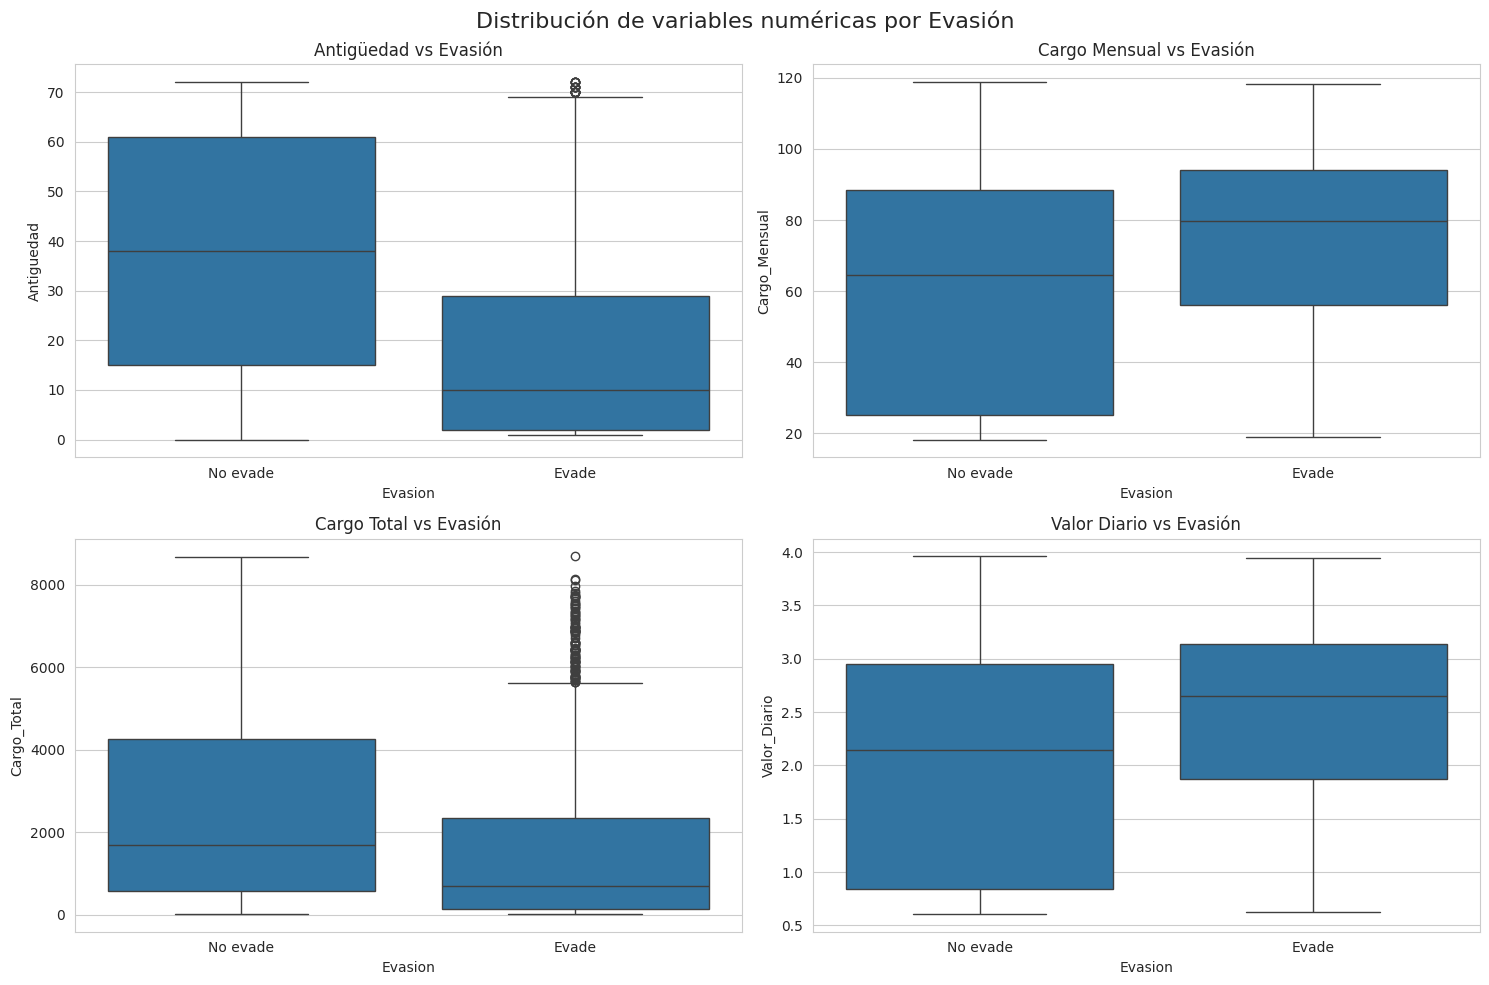

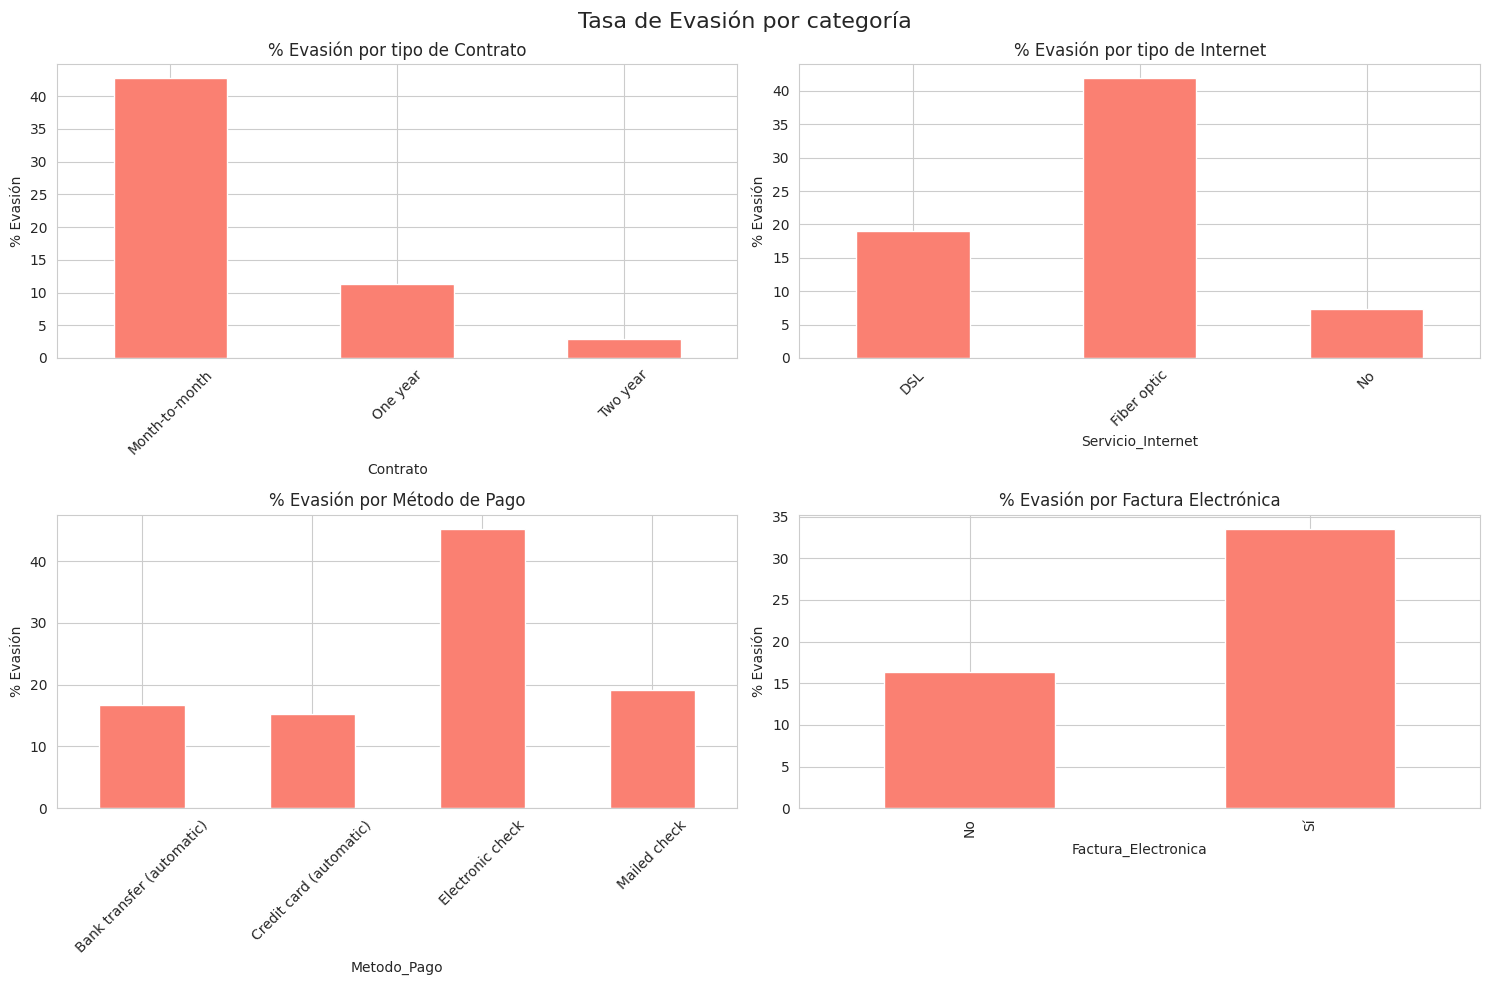

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar estilo
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 5.1 Boxplots de variables numéricas por Evasión
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Distribución de variables numéricas por Evasión', fontsize=16)

sns.boxplot(x='Evasion', y='Antiguedad', data=datos_final, ax=axes[0,0])
axes[0,0].set_title('Antigüedad vs Evasión')
axes[0,0].set_xticklabels(['No evade', 'Evade'])

sns.boxplot(x='Evasion', y='Cargo_Mensual', data=datos_final, ax=axes[0,1])
axes[0,1].set_title('Cargo Mensual vs Evasión')
axes[0,1].set_xticklabels(['No evade', 'Evade'])

sns.boxplot(x='Evasion', y='Cargo_Total', data=datos_final, ax=axes[1,0])
axes[1,0].set_title('Cargo Total vs Evasión')
axes[1,0].set_xticklabels(['No evade', 'Evade'])

sns.boxplot(x='Evasion', y='Valor_Diario', data=datos_final, ax=axes[1,1])
axes[1,1].set_title('Valor Diario vs Evasión')
axes[1,1].set_xticklabels(['No evade', 'Evade'])

plt.tight_layout()
plt.show()

# 5.2 Barras para variables categóricas clave
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Tasa de Evasión por categoría', fontsize=16)

# Contrato
contrato_evasion = pd.crosstab(datos_final['Contrato'], datos_final['Evasion'], normalize='index') * 100
contrato_evasion[1].plot(kind='bar', ax=axes[0,0], color='salmon')
axes[0,0].set_title('% Evasión por tipo de Contrato')
axes[0,0].set_ylabel('% Evasión')
axes[0,0].tick_params(axis='x', rotation=45)

# Internet
internet_evasion = pd.crosstab(datos_final['Servicio_Internet'], datos_final['Evasion'], normalize='index') * 100
internet_evasion[1].plot(kind='bar', ax=axes[0,1], color='salmon')
axes[0,1].set_title('% Evasión por tipo de Internet')
axes[0,1].set_ylabel('% Evasión')
axes[0,1].tick_params(axis='x', rotation=45)

# Método de pago
pago_evasion = pd.crosstab(datos_final['Metodo_Pago'], datos_final['Evasion'], normalize='index') * 100
pago_evasion[1].plot(kind='bar', ax=axes[1,0], color='salmon')
axes[1,0].set_title('% Evasión por Método de Pago')
axes[1,0].set_ylabel('% Evasión')
axes[1,0].tick_params(axis='x', rotation=45)

# Factura electrónica
factura_evasion = pd.crosstab(datos_final['Factura_Electronica'], datos_final['Evasion'], normalize='index') * 100
factura_evasion[1].plot(kind='bar', ax=axes[1,1], color='salmon')
axes[1,1].set_title('% Evasión por Factura Electrónica')
axes[1,1].set_ylabel('% Evasión')
axes[1,1].set_xticklabels(['No', 'Sí'])

plt.tight_layout()
plt.show()

In [59]:
tasa_global = datos_final['Evasion'].mean() * 100
print(f"Tasa global de evasión: {tasa_global:.1f}%")

Tasa global de evasión: 26.5%
